<a href="https://colab.research.google.com/github/anhtin18/SGU26_Ml/blob/main/pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pandas

In [10]:
import pandas as pd
import numpy as np

# Tạo dữ liệu ngẫu nhiên mô phỏng tập Banknote (100 dòng, 5 cột)
np.random.seed(42)
data = np.random.randn(100, 4)  # 4 cột đặc trưng
target = np.random.randint(0, 2, size=(100, 1))  # Cột Class (0 hoặc 1)

# Ghép dữ liệu lại thành một bảng
dataset = np.hstack([data, target])

# Tạo DataFrame (Chưa có tên cột vì code của bạn sẽ tự gán tên sau)
df_to_save = pd.DataFrame(dataset)

# Lưu thành file /content/banknote.csv
df_to_save.to_csv('/content/banknote.csv', index=False)

print("Đã tạo file /content/banknote.csv phù hợp với bài tập của bạn!")

Đã tạo file /content/banknote.csv phù hợp với bài tập của bạn!


In [11]:
import pandas as pd

In [12]:
# from the cheatsheet....
df = pd.DataFrame(
    [[4, 7, 10],
    [5, 8, 11],
    [6, 9, 12]],
    index=[1, 2, 3],
    columns=['a', 'b', 'c'])

df

,a,b,c
1,4,7,10
2,5,8,11
3,6,9,12


In [13]:
# Read dataset
df = pd.read_csv('/content/banknote.csv')#, index_col=0)
df.head()

,0,1,2,3,4
0,0.496714,-0.138264,0.647689,1.523030,0.0
1,-0.234153,-0.234137,1.579213,0.767435,0.0
2,-0.469474,0.542560,-0.463418,-0.465730,0.0
3,0.241962,-1.913280,-1.724918,-0.562288,0.0
4,-1.012831,0.314247,-0.908024,-1.412304,1.0


In [14]:
# Let's rename the columns..

print("original names: ", df.columns)
df.columns = ['dogs', 'cats', 'pigs', 'sheep', 'Class']
df.tail()

original names:  Index(['0', '1', '2', '3', '4'], dtype='object')


,dogs,cats,pigs,sheep,Class
95,-0.839722,-0.599393,-2.123896,-0.525755,1.0
96,-0.759133,0.150394,0.341756,1.876171,0.0
97,0.950424,-0.576904,-0.898415,0.491919,0.0
98,-1.320233,1.831459,1.179440,-0.469176,0.0
99,-1.713135,1.353872,-0.114540,1.237816,0.0


In [15]:
df[['dogs','cats','Class']]

,dogs,cats,Class
0,0.496714,-0.138264,0.0
1,-0.234153,-0.234137,0.0
2,-0.469474,0.542560,0.0
3,0.241962,-1.913280,0.0
4,-1.012831,0.314247,1.0
...,...,...,...
95,-0.839722,-0.599393,1.0
96,-0.759133,0.150394,0.0
97,0.950424,-0.576904,0.0
98,-1.320233,1.831459,0.0


In [16]:
df.describe()

,dogs,cats,pigs,sheep,Class
count,100.000000,100.000000,100.000000,100.000000,100.00
mean,-0.009811,0.033746,0.022496,0.043764,0.45
std,0.868065,0.952234,1.044014,0.982240,0.50
min,-2.025143,-1.959670,-3.241267,-1.987569,0.00
25%,-0.716089,-0.564362,-0.616727,-0.727600,0.00
50%,-0.000248,-0.024646,0.068665,0.075219,0.00
75%,0.528231,0.547116,0.701519,0.778891,1.00
max,2.314659,3.852731,2.189803,2.720169,1.00


In [17]:
df['new'] = df.dogs * df.dogs
df

,dogs,cats,pigs,sheep,Class,new
0,0.496714,-0.138264,0.647689,1.523030,0.0,0.246725
1,-0.234153,-0.234137,1.579213,0.767435,0.0,0.054828
2,-0.469474,0.542560,-0.463418,-0.465730,0.0,0.220406
3,0.241962,-1.913280,-1.724918,-0.562288,0.0,0.058546
4,-1.012831,0.314247,-0.908024,-1.412304,1.0,1.025827
...,...,...,...,...,...,...
95,-0.839722,-0.599393,-2.123896,-0.525755,1.0,0.705133
96,-0.759133,0.150394,0.341756,1.876171,0.0,0.576282
97,0.950424,-0.576904,-0.898415,0.491919,0.0,0.903305
98,-1.320233,1.831459,1.179440,-0.469176,0.0,1.743016


<Axes: ylabel='Frequency'>

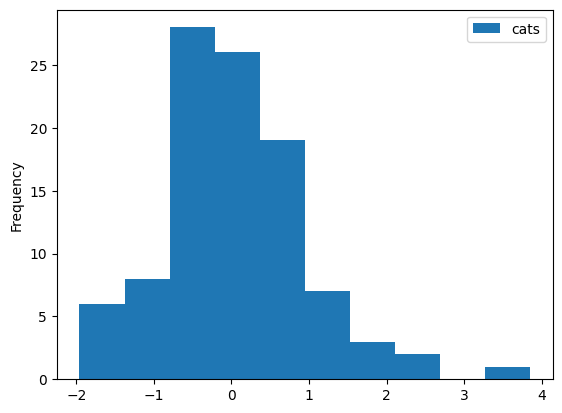

In [18]:
# dataframes can do some simple plots themselves...

df.plot.hist(y=['cats'])
#df.plot.hist(y=['cats','pigs'])
#df.plot.scatter(x='cats', y='pigs')

In [19]:
import seaborn as sns  # optional! Just prettier plotting

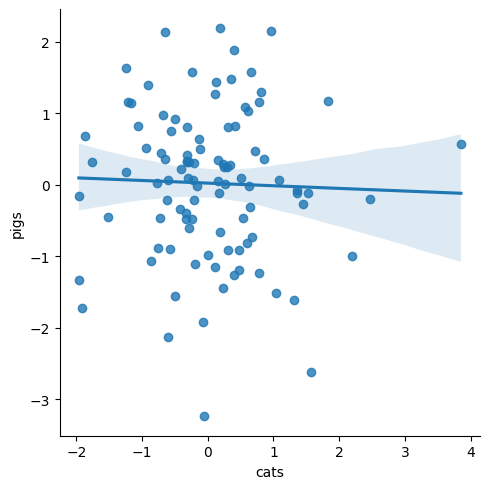

In [20]:
sns.lmplot(x='cats',y='pigs',data=df)   # nb. fits a regression line by default

(0.0, 4.143351571381446)

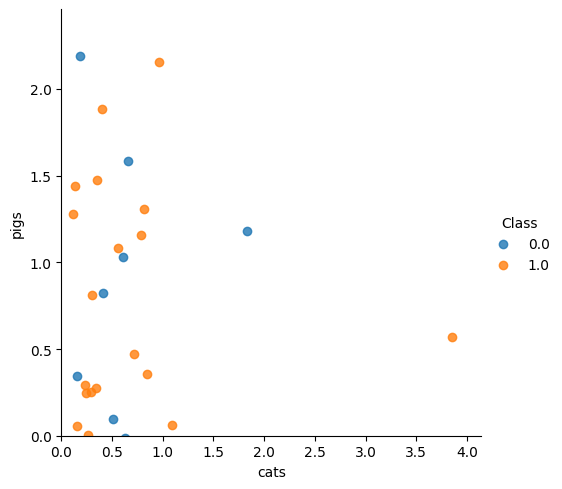

In [22]:
import matplotlib.pyplot as plt
sns.lmplot(x='cats',y='pigs',fit_reg=False, hue='Class', data=df)

# and, optionally, tweak stuff using Matplotlib
plt.ylim(0, None)
plt.xlim(0, None)

In [ ]:
from sklearn import datasets
data = datasets.load_iris()
data # this is like a dict so far, not a dataframe...

df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

In [ ]:
X, Y = datasets.make_blobs(30,4)
Y = np.atleast_2d(Y).T
fig, ax = plt.subplots(1,3)
ax[0].imshow(X)
ax[1].imshow(Y, cmap='hot')

from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(Y)
ax[2].imshow(enc.transform(Y).toarray())